# 08 - Exploration du silver

In [2]:
import sys
sys.path.insert(0, "..")  # accès à src/
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pyiceberg.catalog.sql import SqlCatalog
 
from src.config.settings import (
    CATALOG_URI,
    CATALOG_WAREHOUSE,
    SILVER_STORAGE_ACCOUNT_NAME,
    SILVER_STORAGE_ACCOUNT_KEY,
)

In [3]:
TARGET_DATE = "2026-05-15"
 
# Fenêtre de la moyenne mobile (en nombre de plateaux)
ROLLING_WINDOW = 50
 
# Couleurs par cellule (10 couleurs distinctes)
CELL_COLORS = [
    "#E63946", "#F4A261", "#2A9D8F", "#457B9D", "#A8DADC",
    "#6A0572", "#F77F00", "#06A77D", "#D62246", "#4CC9F0",
]

In [10]:
catalog = SqlCatalog(
    "hatchlog_dev",
    **{
        "uri":               CATALOG_URI,
        "warehouse":         CATALOG_WAREHOUSE,
        "adls.account-name": SILVER_STORAGE_ACCOUNT_NAME,
        "adls.account-key":  SILVER_STORAGE_ACCOUNT_KEY,
    }
)
 
table = catalog.load_table("silver.trays")
print(f"Table chargée — {len(table.snapshots())} snapshots")
print(f"Location : {table.location()}")

Table chargée — 184 snapshots
Location : abfss://silver@dlsecatcandlingfrcedev.dfs.core.windows.net/trays_iceberg


In [11]:
year, month, day = [int(x) for x in TARGET_DATE.split("-")]
 
scan = table.scan(
    row_filter=(
        f"year == {year} AND month == {month} AND day == {day}"
    ),
    selected_fields=("tray_id", "machine_id", "candled_at", "matrix_compact"),
)
 
arrow_table = scan.to_arrow()
df = arrow_table.to_pandas()
 
print(f"Plateaux chargés : {len(df)}")
print(f"Colonnes : {df.columns.tolist()}")
df.head(3)

Plateaux chargés : 1344
Colonnes : ['tray_id', 'machine_id', 'candled_at', 'matrix_compact']


,tray_id,machine_id,candled_at,matrix_compact
0,274d85ce134448b11775aade158296238ed2a7ff0a8f8d...,PMAF-C012501,2026-05-15 07:57:04.337643+00:00,1111111111111111134111111111111111111111411111...
1,824ce90ab1cbec012e888297099a5c1abb592aec3c041d...,PMAF-C012501,2026-05-15 07:57:11.819370+00:00,1111111111114114111211111131111341111111111111...
2,ef58033d024d24f18a81b7cf076b4c4d2f11662cec7abe...,PMAF-C012501,2026-05-15 07:57:28.697491+00:00,3111114113113411131111111314311411411143111141...


In [13]:
assert df["matrix_compact"].str.len().eq(150).all(), \
    "Des matrix_compact ont une longueur != 150 !"
print(f" Toutes les matrices font 150 chars")
print(f"  machine_id unique : {df['machine_id'].unique()}")

 Toutes les matrices font 150 chars
  machine_id unique : <ArrowStringArray>
['PMAF-C012501']
Length: 1, dtype: str


In [14]:
def extract_clear_rates(matrix_compact: str) -> list[float]:
    """
    Pour une matrix_compact de 150 chars (row-major, 15×10),
    retourne la liste des 10 taux de clairs par colonne (C01→C10).
 
    Colonne j (0-based) → indices j, j+10, j+20, ..., j+140
    Classe 3 = Clear
    """
    rates = []
    for j in range(10):
        col_values = [matrix_compact[j + r * 10] for r in range(15)]
        n_clear = col_values.count("3")
        rates.append(n_clear / 15 * 100)
    return rates
 


In [15]:
# Trier par timestamp (ordre de passage sur la machine)
df = df.sort_values("candled_at").reset_index(drop=True)
df["tray_index"] = df.index  # 0-based

In [ ]:
 # Appliquer l'extraction
rates_matrix = df["matrix_compact"].apply(extract_clear_rates)
rates_df = pd.DataFrame(
    rates_matrix.tolist(),
    columns=[f"C{j+1:02d}" for j in range(10)],
    index=df.index,
)

In [17]:
df_rates = pd.concat([df[["tray_index", "candled_at", "machine_id"]], rates_df], axis=1)
 
print(f"Shape : {df_rates.shape}")
df_rates.head(5)
 

Shape : (1344, 13)


,tray_index,candled_at,machine_id,C01,C02,C03,C04,C05,C06,C07,C08,C09,C10
0,0,2026-05-15 04:32:48.638548+00:00,PMAF-C012501,13.333333,0.000000,13.333333,6.666667,6.666667,20.000000,0.000000,13.333333,13.333333,6.666667
1,1,2026-05-15 04:32:54.357327+00:00,PMAF-C012501,13.333333,6.666667,6.666667,13.333333,6.666667,20.000000,0.000000,0.000000,0.000000,13.333333
2,2,2026-05-15 04:33:00.574953+00:00,PMAF-C012501,0.000000,13.333333,6.666667,6.666667,0.000000,0.000000,6.666667,6.666667,6.666667,0.000000
3,3,2026-05-15 04:33:06.604311+00:00,PMAF-C012501,13.333333,0.000000,6.666667,0.000000,6.666667,0.000000,6.666667,6.666667,6.666667,6.666667
4,4,2026-05-15 04:33:13.105761+00:00,PMAF-C012501,20.000000,13.333333,0.000000,6.666667,13.333333,26.666667,0.000000,20.000000,0.000000,6.666667


In [18]:
cell_cols = [f"C{j+1:02d}" for j in range(10)]
 
for col in cell_cols:
    df_rates[f"{col}_ma"] = (
        df_rates[col]
        .rolling(window=ROLLING_WINDOW, min_periods=1, center=False)
        .mean()
    )
 
print(f"Moyennes mobiles calculées (fenêtre = {ROLLING_WINDOW} plateaux)")

Moyennes mobiles calculées (fenêtre = 50 plateaux)


In [23]:
def extract_detection_rates(matrix_compact: str) -> list[float]:
    """
    Taux de détection = % cellules non-missing (code != '0') par colonne.
    """
    rates = []
    for j in range(10):
        col_values = [matrix_compact[j + r * 10] for r in range(15)]
        n_detected = sum(1 for v in col_values if v != "3")
        rates.append(n_detected / 15 * 100)
    return rates


In [24]:
det_matrix = df["matrix_compact"].apply(extract_detection_rates)
det_df = pd.DataFrame(
    det_matrix.tolist(),
    columns=[f"C{j+1:02d}" for j in range(10)],
    index=df.index,
)
df_det = pd.concat([df[["tray_index", "candled_at"]], det_df], axis=1)

# Moyennes mobiles
for col in cell_cols:
    df_det[f"{col}_ma"] = (
        df_det[col]
        .rolling(window=ROLLING_WINDOW, min_periods=1)
        .mean()
    )

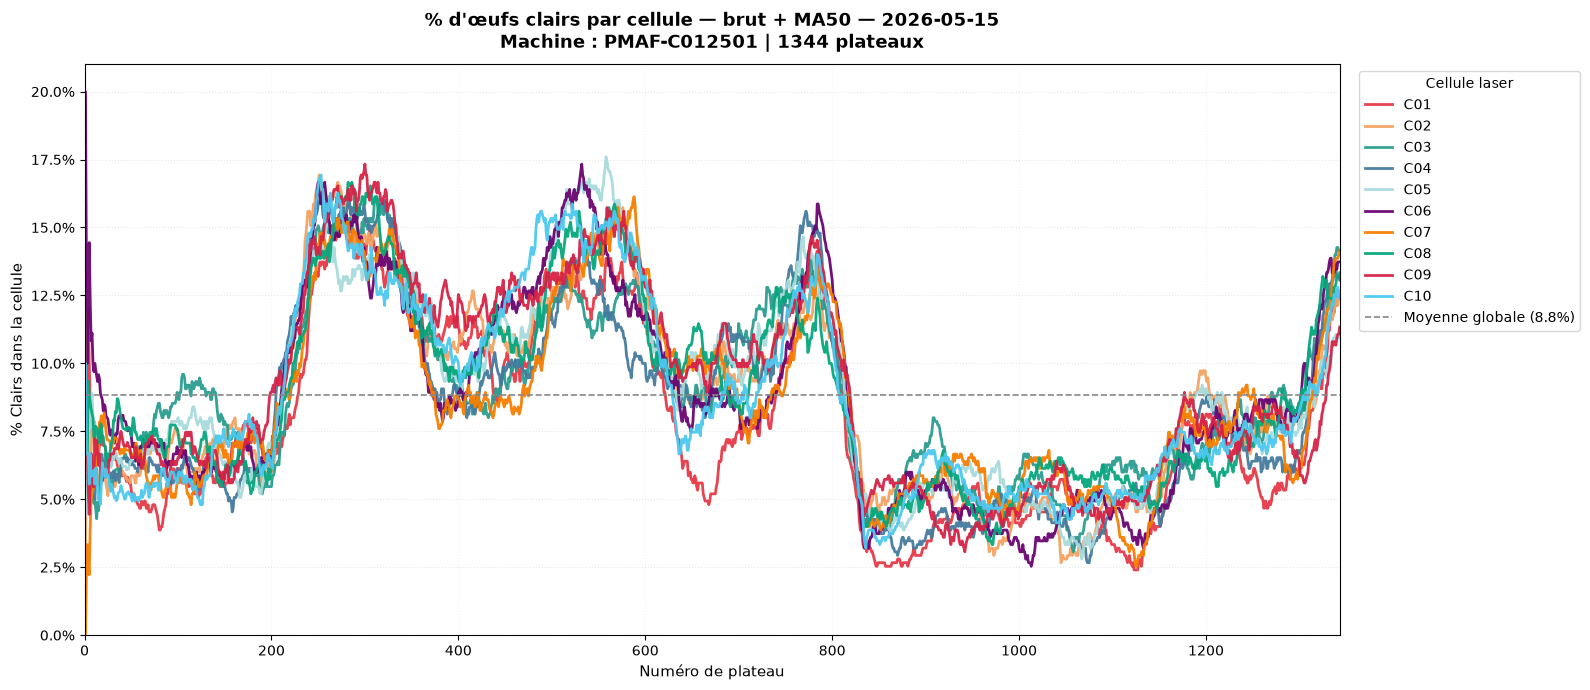

In [30]:
fig, ax = plt.subplots(figsize=(16, 7))

x = df_rates["tray_index"]

for j, col in enumerate(cell_cols):
    color = CELL_COLORS[j]
    # MA50
    ax.plot(x, df_rates[f"{col}_ma"],
            color=color, linewidth=2.0, alpha=0.95, zorder=2, label=col)

global_mean = df_rates[cell_cols].values.mean()
ax.axhline(global_mean, color="#888888", linewidth=1.2, linestyle="--",
           label=f"Moyenne globale ({global_mean:.1f}%)")

ax.set_title(
    f"% d'œufs clairs par cellule — brut + MA{ROLLING_WINDOW} — {TARGET_DATE}\n"
    f"Machine : {df['machine_id'].iloc[0]} | {len(df)} plateaux",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Numéro de plateau", fontsize=11)
ax.set_ylabel("% Clairs dans la cellule", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_xlim(0, len(df) - 1)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.grid(axis="x", alpha=0.15, linestyle=":")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=10, title="Cellule laser")

plt.tight_layout()
plt.show()

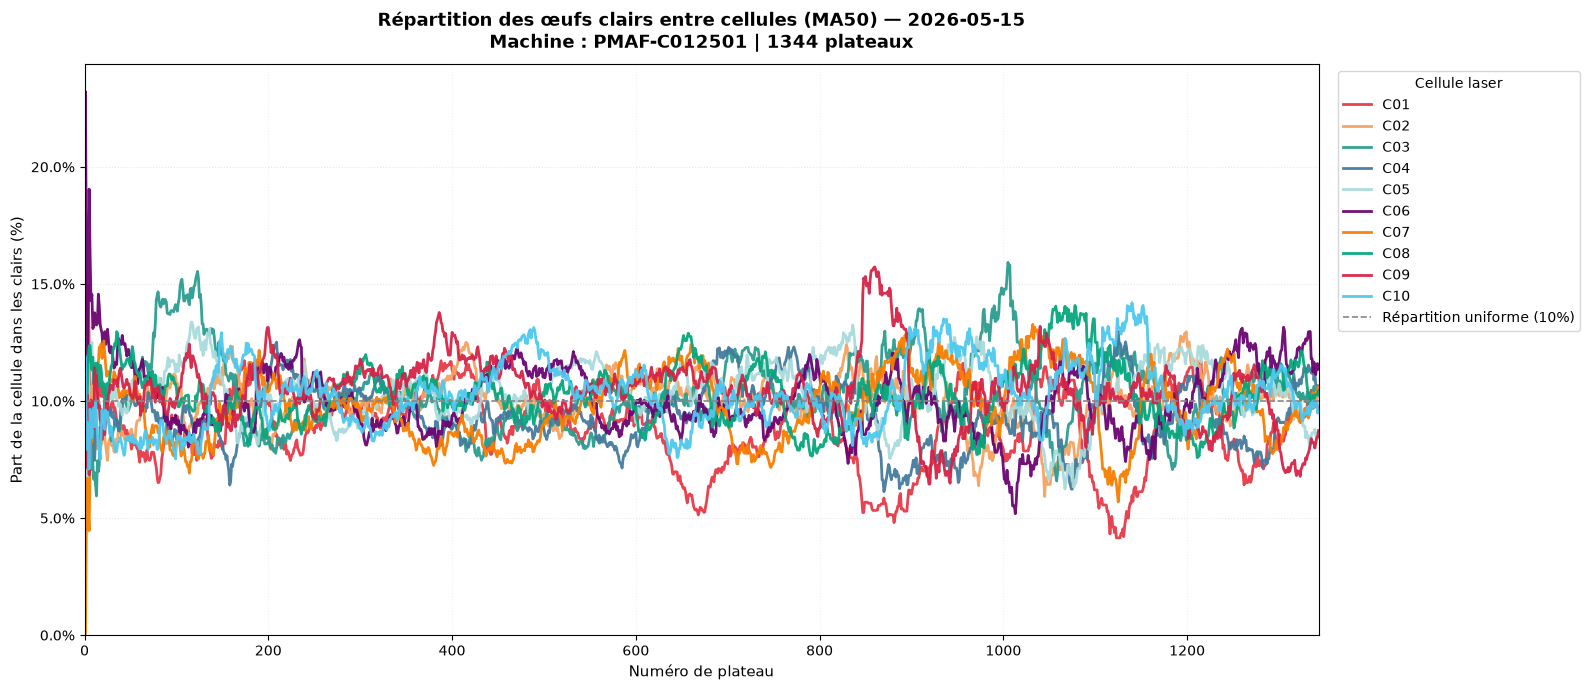

In [29]:
fig, ax = plt.subplots(figsize=(16, 7))

for j, col in enumerate(cell_cols):
    color = CELL_COLORS[j]
    # MA50
    ax.plot(x, share_ma[col],
            color=color, linewidth=2.0, alpha=0.95, zorder=2, label=col)

# Répartition uniforme
ax.axhline(10, color="#888888", linewidth=1.2, linestyle="--",
           label="Répartition uniforme (10%)")

ax.set_title(
    f"Répartition des œufs clairs entre cellules (MA{ROLLING_WINDOW}) — {TARGET_DATE}\n"
    f"Machine : {df['machine_id'].iloc[0]} | {len(df)} plateaux",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Numéro de plateau", fontsize=11)
ax.set_ylabel("Part de la cellule dans les clairs (%)", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_xlim(0, len(df) - 1)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.grid(axis="x", alpha=0.15, linestyle=":")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=10, title="Cellule laser")

plt.tight_layout()
plt.show()

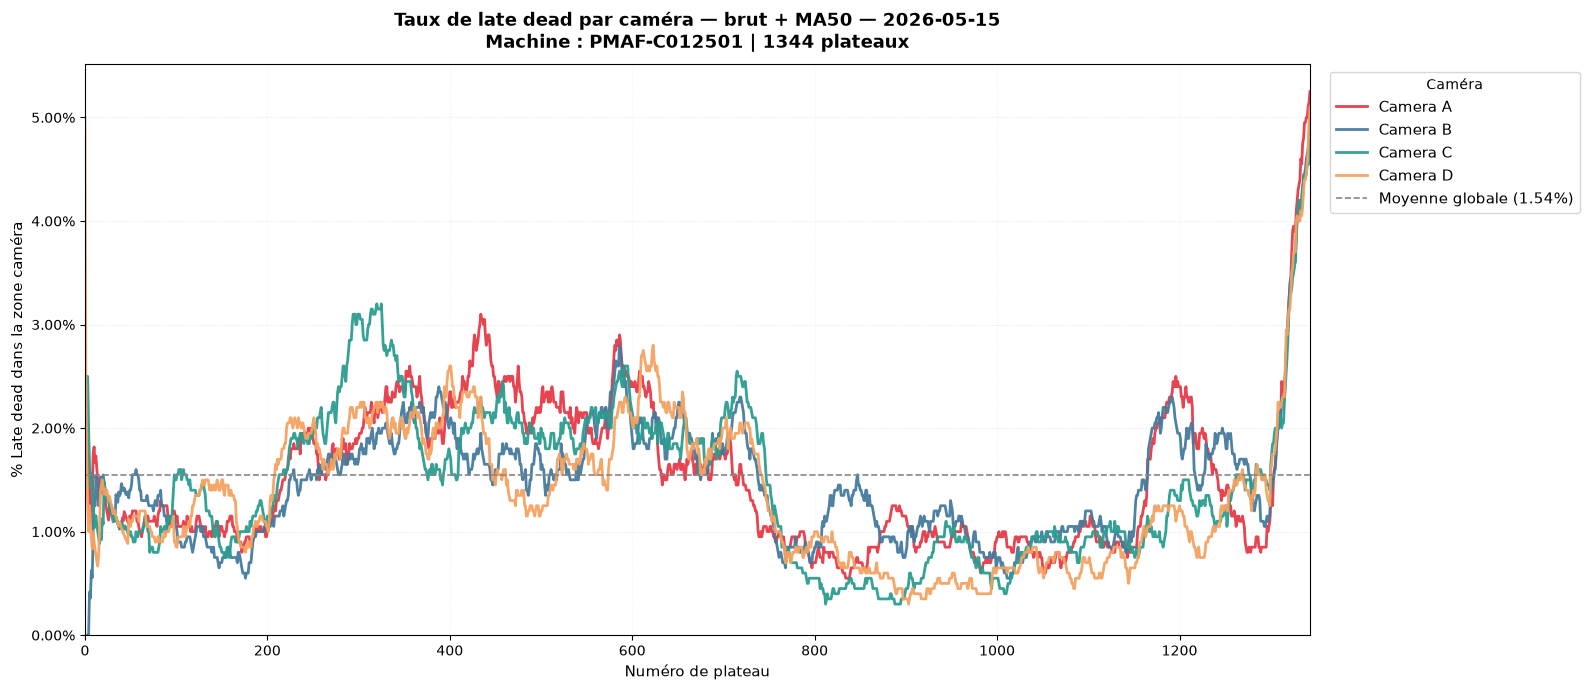

          Moy (%)  Écart-type  Max (%)
Camera A    1.603       2.331     17.5
Camera B    1.564       2.318     15.0
Camera C    1.546       2.272     15.0
Camera D    1.456       2.352     20.0


In [32]:
CAM_ZONES = {
    "Camera A": (7, 14, 0, 4),
    "Camera B": (0,  7, 0, 4),
    "Camera C": (7, 14, 5, 9),
    "Camera D": (0,  7, 5, 9),
}
CAM_COLORS = {
    "Camera A": "#E63946",
    "Camera B": "#457B9D",
    "Camera C": "#2A9D8F",
    "Camera D": "#F4A261",
}

def extract_late_dead_by_cam(matrix_compact: str) -> dict[str, float]:
    """
    Pour chaque caméra, taux de late dead (code '4') dans sa zone.
    taille_zone = 40 positions (8 rangées × 5 colonnes, bornes incluses).
    """
    rates = {}
    for cam, (r_start, r_end, c_start, c_end) in CAM_ZONES.items():
        positions = [
            matrix_compact[r * 10 + c]
            for r in range(r_start, r_end + 1)
            for c in range(c_start, c_end + 1)
        ]
        n_late = positions.count("4")
        rates[cam] = n_late / len(positions) * 100
    return rates

# Extraction
cam_matrix = df["matrix_compact"].apply(extract_late_dead_by_cam)
df_cam = pd.DataFrame(cam_matrix.tolist(), index=df.index)
df_cam = pd.concat([df[["tray_index", "candled_at"]], df_cam], axis=1)

# MA50
cam_cols = list(CAM_ZONES.keys())
for col in cam_cols:
    df_cam[f"{col}_ma"] = (
        df_cam[col]
        .rolling(window=ROLLING_WINDOW, min_periods=1)
        .mean()
    )

# %%
fig, ax = plt.subplots(figsize=(16, 7))

x = df_cam["tray_index"]

for cam in cam_cols:
    color = CAM_COLORS[cam]
    # MA50
    ax.plot(x, df_cam[f"{cam}_ma"],
            color=color, linewidth=2.0, alpha=0.95, zorder=2, label=cam)

global_mean_ld = df_cam[cam_cols].values.mean()
ax.axhline(global_mean_ld, color="#888888", linewidth=1.2, linestyle="--",
           label=f"Moyenne globale ({global_mean_ld:.2f}%)")

ax.set_title(
    f"Taux de late dead par caméra — brut + MA{ROLLING_WINDOW} — {TARGET_DATE}\n"
    f"Machine : {df['machine_id'].iloc[0]} | {len(df)} plateaux",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Numéro de plateau", fontsize=11)
ax.set_ylabel("% Late dead dans la zone caméra", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_xlim(0, len(df) - 1)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.grid(axis="x", alpha=0.15, linestyle=":")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=11, title="Caméra")

plt.tight_layout()
plt.show()

# Stats résumées
summary_cam = df_cam[cam_cols].agg(["mean", "std", "max"]).T
summary_cam.columns = ["Moy (%)", "Écart-type", "Max (%)"]
summary_cam = summary_cam.round(3)
print(summary_cam.to_string())

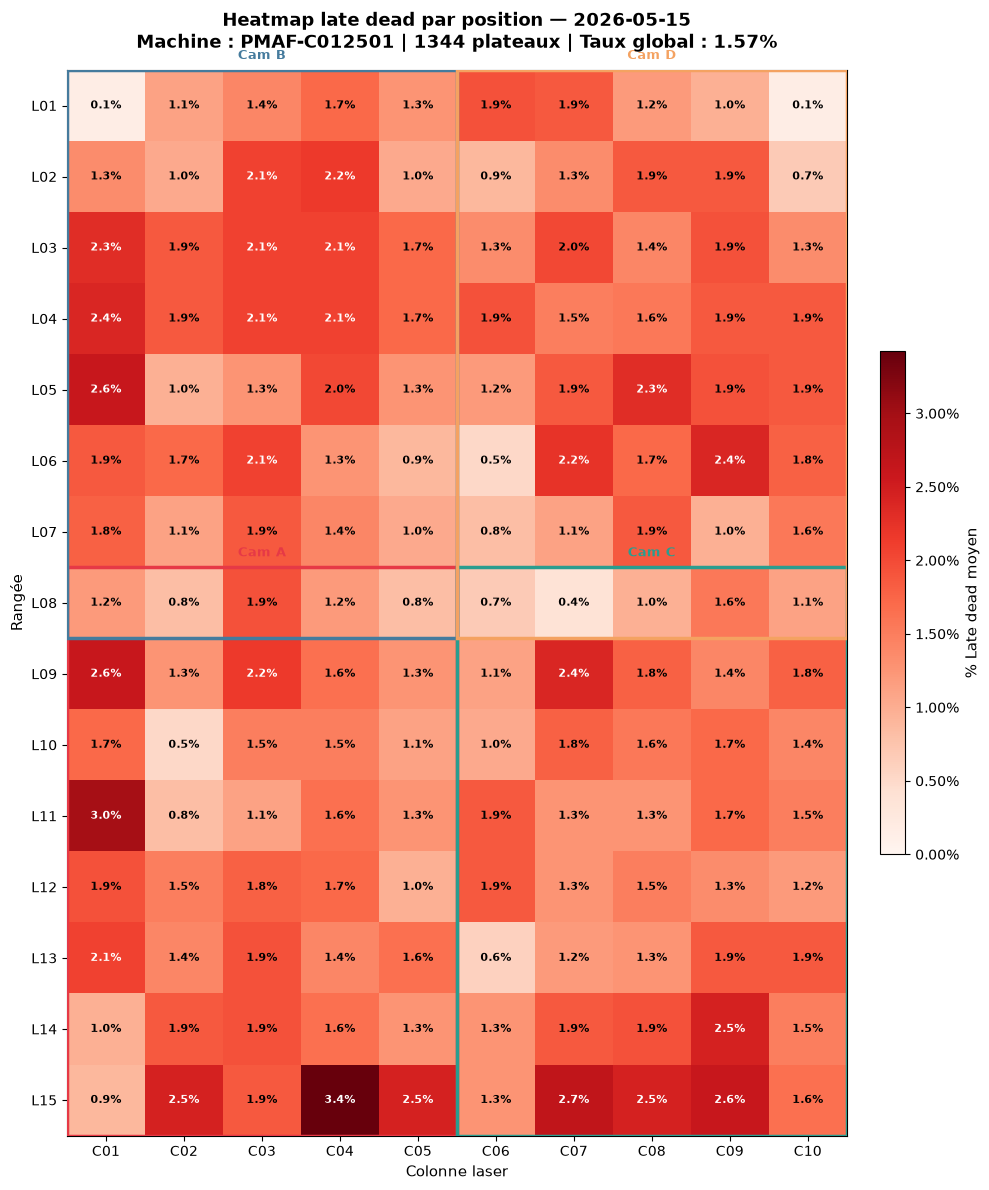

Position la plus touchée : L15 / C04 — 3.42%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Construire la matrice 15×10 des taux moyens de late dead
# Pour chaque position (r, c) : mean(matrix_compact[r*10 + c] == '4') * 100

late_dead_matrix = np.zeros((15, 10))

for r in range(15):
    for c in range(10):
        idx = r * 10 + c
        vals = df["matrix_compact"].str[idx]
        late_dead_matrix[r, c] = (vals == "4").mean() * 100

# %%
fig, ax = plt.subplots(figsize=(10, 12))

# Colormap rouge avec blanc pour les zéros
cmap = plt.cm.Reds
norm = mcolors.Normalize(vmin=0, vmax=late_dead_matrix.max())

im = ax.imshow(late_dead_matrix, cmap=cmap, norm=norm, aspect="auto")

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("% Late dead moyen", fontsize=11)
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# Annotations valeurs dans chaque cellule
for r in range(15):
    for c in range(10):
        val = late_dead_matrix[r, c]
        # Texte blanc si fond foncé, noir si fond clair
        text_color = "white" if val > late_dead_matrix.max() * 0.6 else "black"
        ax.text(c, r, f"{val:.1f}%",
                ha="center", va="center",
                fontsize=8, color=text_color, fontweight="bold")

# Axes
ax.set_xticks(range(10))
ax.set_xticklabels([f"C{j+1:02d}" for j in range(10)], fontsize=10)
ax.set_yticks(range(15))
ax.set_yticklabels([f"L{r+1:02d}" for r in range(15)], fontsize=10)
ax.set_xlabel("Colonne laser", fontsize=11)
ax.set_ylabel("Rangée", fontsize=11)

# Zones caméra — cadres colorés
cam_rects = {
    "A": dict(r=(7, 14), c=(0, 4),  color="#E63946"),
    "B": dict(r=(0,  7), c=(0, 4),  color="#457B9D"),
    "C": dict(r=(7, 14), c=(5, 9),  color="#2A9D8F"),
    "D": dict(r=(0,  7), c=(5, 9),  color="#F4A261"),
}
for cam, zone in cam_rects.items():
    r0, r1 = zone["r"]
    c0, c1 = zone["c"]
    rect = plt.Rectangle(
        (c0 - 0.5, r0 - 0.5),
        c1 - c0 + 1, r1 - r0 + 1,
        linewidth=2.5, edgecolor=zone["color"],
        facecolor="none", zorder=3,
    )
    ax.add_patch(rect)
    # Label caméra
    ax.text(c0 + (c1 - c0) / 2, r0 - 0.7,
            f"Cam {cam}", ha="center", va="center",
            fontsize=9, color=zone["color"], fontweight="bold")

ax.set_title(
    f"Heatmap late dead par position — {TARGET_DATE}\n"
    f"Machine : {df['machine_id'].iloc[0]} | {len(df)} plateaux | "
    f"Taux global : {late_dead_matrix.mean():.2f}%",
    fontsize=13, fontweight="bold", pad=16,
)

plt.tight_layout()
plt.show()

# Position la plus touchée
r_max, c_max = np.unravel_index(late_dead_matrix.argmax(), late_dead_matrix.shape)
print(f"Position la plus touchée : L{r_max+1:02d} / C{c_max+1:02d} "
      f"— {late_dead_matrix[r_max, c_max]:.2f}%")

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.patches as mpatches

# Palette couleurs par classe
CLASS_COLORS = {
    "0": "#E2E8F0",  # Missing  — gris clair
    "1": "#22C55E",  # Fertile  — vert
    "2": "#F97316",  # Early dead — orange
    "3": "#EAB308",  # Clear    — jaune
    "4": "#EF4444",  # Late dead — rouge
}
CLASS_LABELS = {
    "0": "Missing",
    "1": "Fertile",
    "2": "Early Dead",
    "3": "Clear",
    "4": "Late Dead",
}

def plot_tray(tray_idx: int):
    row = df.iloc[tray_idx]
    matrix_compact = row["matrix_compact"]

    # Reconstruction matrice 15×10 en codes entiers
    matrix = np.array(
        [int(matrix_compact[r * 10 + c]) for r in range(15) for c in range(10)]
    ).reshape(15, 10)

    # Matrice de couleurs RGB
    color_matrix = np.zeros((15, 10, 3))
    for r in range(15):
        for c in range(10):
            hex_color = CLASS_COLORS[str(matrix[r, c])]
            color_matrix[r, c] = mcolors.to_rgb(hex_color)

    # Comptages
    counts = {k: (matrix == int(k)).sum() for k in CLASS_COLORS}

    fig, ax = plt.subplots(figsize=(10, 9))
    ax.imshow(color_matrix, aspect="auto")

    # Grille
    for r in range(16):
        ax.axhline(r - 0.5, color="white", linewidth=0.8, alpha=0.6)
    for c in range(11):
        ax.axvline(c - 0.5, color="white", linewidth=0.8, alpha=0.6)

    # Axes
    ax.set_xticks(range(10))
    ax.set_xticklabels([f"C{j+1:02d}" for j in range(10)], fontsize=9)
    ax.set_yticks(range(15))
    ax.set_yticklabels([f"L{r+1:02d}" for r in range(15)], fontsize=9)

    # Zones caméra
    for cam, zone in cam_rects.items():
        r0, r1 = zone["r"]
        c0, c1 = zone["c"]
        rect = plt.Rectangle(
            (c0 - 0.5, r0 - 0.5),
            c1 - c0 + 1, r1 - r0 + 1,
            linewidth=2.5, edgecolor=zone["color"],
            facecolor="none", zorder=3,
        )
        ax.add_patch(rect)
        ax.text(c0 + (c1 - c0) / 2, r0 - 0.72,
                f"Cam {cam}", ha="center", va="center",
                fontsize=8, color=zone["color"], fontweight="bold")

    # Titre
    ts = pd.Timestamp(row["candled_at"])
    ax.set_title(
        f"Plateau #{tray_idx + 1} / {len(df)}  —  {ts.strftime('%H:%M:%S')}\n"
        f"Fertile: {counts['1']}  |  Clear: {counts['3']}  |  "
        f"Early Dead: {counts['2']}  |  Late Dead: {counts['4']}  |  Missing: {counts['0']}",
        fontsize=12, fontweight="bold", pad=12,
    )

    # Légende
    patches = [
        mpatches.Patch(color=CLASS_COLORS[k], label=f"{CLASS_LABELS[k]} ({counts[k]})")
        for k in ["1", "3", "2", "4", "0"]
    ]
    ax.legend(handles=patches, loc="upper left", bbox_to_anchor=(1.01, 1),
              fontsize=10, title="Classe", framealpha=0.95)

    plt.tight_layout()
    plt.show()

# %%
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df) - 1,
    step=1,
    description="Plateau :",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
    style={"description_width": "80px"},
)

widgets.interact(plot_tray, tray_idx=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Plateau :', layout=Layout(width…

<function __main__.plot_tray(tray_idx: int)>

In [35]:
# %% [markdown]
# ## 12. Tableau récapitulatif journée

# %%
from IPython.display import display
import pandas as pd

# ── Stats globales ────────────────────────────────────────────────────────────
total_plateaux = len(df)
total_oeufs    = total_plateaux * 150

# Comptages globaux depuis matrix_compact
all_chars = df["matrix_compact"].str.cat()  # concatène toutes les matrices
n_fertile   = all_chars.count("1")
n_clear     = all_chars.count("3")
n_early     = all_chars.count("2")
n_late      = all_chars.count("4")
n_missing   = all_chars.count("0")

ts_start = pd.Timestamp(df["candled_at"].min())
ts_end   = pd.Timestamp(df["candled_at"].max())
duree    = ts_end - ts_start

df_global = pd.DataFrame([{
    "Plateaux"        : total_plateaux,
    "Œufs total"      : total_oeufs,
    "Fertiles"        : f"{n_fertile}  ({n_fertile/total_oeufs*100:.1f}%)",
    "Clairs"          : f"{n_clear}  ({n_clear/total_oeufs*100:.1f}%)",
    "Morts précoces"  : f"{n_early}  ({n_early/total_oeufs*100:.1f}%)",
    "Morts tardifs"   : f"{n_late}  ({n_late/total_oeufs*100:.1f}%)",
    "Manquants"       : f"{n_missing}  ({n_missing/total_oeufs*100:.1f}%)",
    "Début"           : ts_start.strftime("%H:%M:%S"),
    "Fin"             : ts_end.strftime("%H:%M:%S"),
    "Durée"           : str(duree).split(".")[0],
}]).T.rename(columns={0: "Valeur"})

print("── Stats globales ──────────────────────────────")
display(df_global)

# ── Late dead par caméra ──────────────────────────────────────────────────────
cam_rows = []
for cam, (r_start, r_end, c_start, c_end) in CAM_ZONES.items():
    zone_size = (r_end - r_start + 1) * (c_end - c_start + 1)  # 40
    total_positions = total_plateaux * zone_size

    n_ld = sum(
        df["matrix_compact"].apply(
            lambda m: sum(
                1 for r in range(r_start, r_end + 1)
                for c in range(c_start, c_end + 1)
                if m[r * 10 + c] == "4"
            )
        )
    )
    cam_rows.append({
        "Caméra"          : cam,
        "Positions totales": total_positions,
        "Late dead (n)"   : n_ld,
        "Taux (%)"        : round(n_ld / total_positions * 100, 3),
    })

df_cam_recap = pd.DataFrame(cam_rows).set_index("Caméra")

print("\n── Late dead par caméra ────────────────────────")
display(df_cam_recap)

# ── Clairs par cellule laser ──────────────────────────────────────────────────
total_per_col = total_plateaux * 15  # 15 rangées par colonne

cell_rows = []
for j in range(10):
    col_chars = df["matrix_compact"].apply(lambda m: m[j::10][:15])
    n_clear_col = col_chars.str.count("3").sum()
    cell_rows.append({
        "Cellule"        : f"C{j+1:02d}",
        "Clairs (n)"     : int(n_clear_col),
        "Taux (%)"       : round(n_clear_col / total_per_col * 100, 2),
    })

df_cell_recap = pd.DataFrame(cell_rows).set_index("Cellule")

# Highlighting : cellule dominante en gras
mean_clear = df_cell_recap["Taux (%)"].mean()
df_cell_recap["vs moyenne"] = (df_cell_recap["Taux (%)"] - mean_clear).round(2)
df_cell_recap["vs moyenne"] = df_cell_recap["vs moyenne"].apply(
    lambda v: f"+{v:.2f}pp" if v >= 0 else f"{v:.2f}pp"
)

print(f"\n── Clairs par cellule laser (moyenne = {mean_clear:.2f}%) ──")
display(df_cell_recap)

── Stats globales ──────────────────────────────


,Valeur
Plateaux,1344
Œufs total,201600
Fertiles,178908 (88.7%)
Clairs,17804 (8.8%)
Morts précoces,1614 (0.8%)
Morts tardifs,3174 (1.6%)
Manquants,100 (0.0%)
Début,04:32:48
Fin,07:57:28
Durée,0 days 03:24:40



── Late dead par caméra ────────────────────────


,Positions totales,Late dead (n),Taux (%)
Caméra,,,
Camera A,53760,862,1.603
Camera B,53760,841,1.564
Camera C,53760,831,1.546
Camera D,53760,783,1.456



── Clairs par cellule laser (moyenne = 8.83%) ──


,Clairs (n),Taux (%),vs moyenne
Cellule,,,
C01,1613,8.00,-0.83pp
C02,1804,8.95,+0.12pp
C03,1824,9.05,+0.22pp
C04,1707,8.47,-0.36pp
C05,1831,9.08,+0.25pp
C06,1780,8.83,+-0.00pp
C07,1760,8.73,-0.10pp
C08,1821,9.03,+0.20pp
C09,1861,9.23,+0.40pp
